# Approach 1: RMS Energy Baseline

This notebook implements the **simplest possible speech activity detection** using classical signal processing — no neural models, no machine learning.

The core idea: speech produces more acoustic energy than silence. By computing frame-level RMS (Root Mean Square) energy and thresholding it, we can find regions of the audio where something loud is happening.

Pipeline:
1. Load audio as mono 16 kHz.
2. Compute per-frame RMS energy using a 32 ms window at 10 ms hop.
3. Set a **relative threshold** at 15% of the file's 95th-percentile RMS — adaptive to recording volume.
4. Mark frames above threshold as active; suppress runs shorter than 3 frames (impulse noise filter).
5. Convert frame runs to time segments, then apply the same merge/split logic as all other approaches.
6. Select the top-2 longest conversation candidates as the final answer.

**Key limitation:**
> Energy thresholding cannot distinguish speech from other loud sounds. Background shop noise, metal clanging, music, or a loud HVAC system can all cross the threshold and be misidentified as speech. This is exactly the problem that Approach 2 (Silero VAD) solves by using a neural model trained specifically to recognise human speech patterns regardless of volume.

**Why start here:**
> Every added model brings assumptions, latency, dependencies, and failure modes. Starting with the dumbest possible baseline tells you how much signal is in the raw acoustics, gives you a performance floor to beat, and validates the audio loading and downstream pipeline before adding any complexity.

In [1]:
# # If running in Colab / fresh environment:
# !pip install -q librosa torchaudio soundfile matplotlib pandas numpy

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import librosa

import torch
import torchaudio


In [3]:
import os
def get_safe_start_dirs() -> list[Path]:
    """Return possible project locations even if the kernel cwd was deleted."""
    starts = []

    try:
        starts.append(Path.cwd().resolve())
    except FileNotFoundError:
        print("Current working directory no longer exists; trying known project locations.")

    for value in (os.environ.get("PWD"), os.environ.get("OLDPWD")):
        if value:
            starts.append(Path(value).expanduser())

    starts.extend(
        [
            Path("/teamspace/studios/this_studio"),
            Path("/teamspace/studios/this_studio/approaches"),
            Path("/teamspace"),
            Path.home(),
            Path("/content"),
        ]
    )

    unique_starts = []
    seen = set()
    for start in starts:
        try:
            resolved = start.resolve()
        except FileNotFoundError:
            continue
        if resolved in seen:
            continue
        seen.add(resolved)
        unique_starts.append(resolved)
    return unique_starts


def find_project_root(start: Path | None = None) -> Path:
    starts = [start.resolve()] if start is not None else get_safe_start_dirs()

    checked = []
    for start_dir in starts:
        for candidate in [start_dir, *start_dir.parents]:
            checked.append(str(candidate))
            has_audio = (candidate / "audio").exists()
            has_repo_marker = (candidate / "ground_truth.json").exists() or (candidate / "approaches").exists() or (candidate / "context.md").exists()
            if has_audio and has_repo_marker:
                return candidate
            if candidate.name == "approaches" and (candidate.parent / "audio").exists():
                return candidate.parent

    raise FileNotFoundError(
        "Could not find project root. Expected a folder containing audio/ and ground_truth.json or approaches/. "
        f"Checked: {checked}"
    )


PROJECT_ROOT = find_project_root()
OUTPUT_DIR = PROJECT_ROOT / "approaches" / "approach_1_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "audio_dir": PROJECT_ROOT / "audio",
    "output_dir": OUTPUT_DIR,
    "target_sr": 16000,
    # ── Energy baseline parameters ──────────────────────────────────────────
    # Frame size and hop for RMS energy computation.
    # frame_length = 512 samples = 32 ms at 16 kHz. Chosen to be short enough
    # to resolve individual phonemes but long enough to smooth burst noise.
    "frame_length": 512,
    "hop_length": 160,       # 10 ms hop — standard for speech analysis
    # Relative energy threshold: frames whose RMS exceeds this fraction of the
    # file's 95th-percentile RMS are marked as active speech.
    # Using a relative threshold makes the detector adaptive to overall volume.
    "energy_threshold_rel": 0.15,
    # Minimum number of consecutive active frames to count as a speech onset.
    # 3 frames * 10 ms = 30 ms — filters single-frame clicks and impulse noise.
    "min_active_frames": 3,
    # ── Downstream merge / split (same as Approach 2 for fair comparison) ───
    "merge_gap_s": 1.0,
    "min_region_s": 1.5,
    "conversation_gap_s": 5.0,
    "plot_width": 18,
    "plot_height": 4,
}

audio_files = sorted(CONFIG["audio_dir"].glob("*.mp3"))

import sys
sys.path.append(str(PROJECT_ROOT / "approaches"))
from output_utils import load_ground_truth, export_uniform_outputs, export_combined_outputs

GROUND_TRUTH = load_ground_truth(PROJECT_ROOT)
print("Audio dir:", CONFIG["audio_dir"])
print("Audio files:", [path.name for path in audio_files])
print("Outputs:", OUTPUT_DIR)


Audio dir: /teamspace/studios/this_studio/audio
Audio files: ['Sample1KN.mp3', 'Sample2EN.mp3', 'sample3KN.mp3']
Outputs: /teamspace/studios/this_studio/approaches/approach_1_outputs


In [4]:
def format_time(seconds: float) -> str:
    minutes = int(seconds // 60)
    secs = seconds % 60
    return f"{minutes:02d}:{secs:06.3f}"


def load_audio_mono_resampled(path: str, target_sr: int = 16000):
    """
    Load audio as mono 16 kHz.

    Lightning/Linux environments often have torchaudio installed without MP3 codec support.
    Use librosa/audioread first because it is more reliable for MP3 files, and keep
    torchaudio as a fallback for environments where it works.
    """
    try:
        audio, sr = librosa.load(path, sr=target_sr, mono=True)
        waveform = torch.from_numpy(audio).float().contiguous()
        return waveform, target_sr
    except Exception as librosa_error:
        print(f"librosa failed to load {path}: {librosa_error}. Falling back to torchaudio.")

    try:
        waveform, sr = torchaudio.load(path)
    except Exception as torchaudio_error:
        raise RuntimeError(
            f"Could not load audio file {path}. Install ffmpeg/libsndfile support or use librosa/audioread-compatible audio decoding."
        ) from torchaudio_error

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        waveform = resampler(waveform)
        sr = target_sr

    waveform = waveform.squeeze(0).contiguous()
    return waveform, sr


def run_energy_vad(waveform: torch.Tensor, sr: int, cfg: dict) -> list[dict]:
    """
    Detect active speech regions using frame-level RMS energy.

    This is a classical signal-processing baseline with no learned model.
    It works as follows:
      1. Compute RMS energy for every short frame (512 samples / 32 ms).
      2. Set a threshold at energy_threshold_rel * 95th-percentile RMS.
         Using a relative threshold makes the detector volume-adaptive:
         quiet recordings and loud recordings get equivalent sensitivity.
      3. Mark frames above threshold as active.
      4. Require at least min_active_frames consecutive active frames
         to suppress single-sample clicks, impulse noise, and brief pops.
      5. Convert frame indices back to seconds and return as segment list.

    Key limitation: energy does not distinguish speech from other loud sounds.
    Background shop noise, metal clanging, or music can all cross the threshold.
    This is the core weakness that Approach 2 (Silero VAD) addresses by using
    a neural model trained specifically to recognise speech patterns.
    """
    audio_np = waveform.numpy()
    frame_length = cfg["frame_length"]
    hop_length = cfg["hop_length"]

    # Step 1: per-frame RMS energy
    rms = librosa.feature.rms(
        y=audio_np,
        frame_length=frame_length,
        hop_length=hop_length,
    )[0]  # shape: (n_frames,)

    # Step 2: relative threshold — adaptive to overall recording volume
    ref_level = float(np.percentile(rms, 95))
    threshold = cfg["energy_threshold_rel"] * ref_level
    active = rms > threshold  # boolean mask over frames

    # Step 3: suppress isolated active frames (clicks, pops, impulse noise)
    min_run = cfg["min_active_frames"]
    cleaned = active.copy()
    n = len(active)
    for i in range(n):
        if active[i]:
            run_end = i
            while run_end < n and active[run_end]:
                run_end += 1
            run_len = run_end - i
            if run_len < min_run:
                cleaned[i:run_end] = False

    # Step 4: convert frame runs to (start_s, end_s) segments
    segments = []
    in_segment = False
    seg_start = 0
    for frame_idx, is_active in enumerate(cleaned):
        t = librosa.frames_to_time(frame_idx, sr=sr, hop_length=hop_length)
        if is_active and not in_segment:
            seg_start = t
            in_segment = True
        elif not is_active and in_segment:
            seg_end = t
            segments.append({
                "start": float(seg_start),
                "end": float(seg_end),
                "duration": float(seg_end - seg_start),
            })
            in_segment = False

    # Close any open segment at end of file
    if in_segment:
        seg_end = librosa.frames_to_time(len(cleaned), sr=sr, hop_length=hop_length)
        segments.append({
            "start": float(seg_start),
            "end": float(seg_end),
            "duration": float(seg_end - seg_start),
        })

    return segments, rms, threshold


def merge_close_segments(segments, merge_gap_s=1.0, min_region_s=1.5):
    """
    Merge segments if the gap between them is small.
    """
    if not segments:
        return []

    segments = sorted(segments, key=lambda x: x["start"])
    merged = [segments[0].copy()]

    for seg in segments[1:]:
        last = merged[-1]
        gap = seg["start"] - last["end"]

        if gap <= merge_gap_s:
            last["end"] = max(last["end"], seg["end"])
            last["duration"] = last["end"] - last["start"]
        else:
            merged.append(seg.copy())

    # Filter tiny merged regions
    merged = [m for m in merged if (m["end"] - m["start"]) >= min_region_s]

    # add ids
    for i, seg in enumerate(merged, start=1):
        seg["region_id"] = i
        seg["duration"] = seg["end"] - seg["start"]

    return merged


def assign_conversation_ids(merged_regions, conversation_gap_s=5.0):
    """
    Group merged speech regions into larger conversation candidates.
    If the gap between merged regions is large, start a new conversation group.
    """
    if not merged_regions:
        return []

    merged_regions = sorted(merged_regions, key=lambda x: x["start"])

    conv_id = 1
    merged_regions[0]["conversation_id"] = conv_id

    for i in range(1, len(merged_regions)):
        prev = merged_regions[i - 1]
        curr = merged_regions[i]
        gap = curr["start"] - prev["end"]

        if gap >= conversation_gap_s:
            conv_id += 1

        curr["conversation_id"] = conv_id

    return merged_regions


def collapse_conversation_groups(regions):
    """
    Convert region-level rows into conversation-level start/end windows.
    """
    if not regions:
        return []

    df = pd.DataFrame(regions)
    grouped = (
        df.groupby("conversation_id", as_index=False)
          .agg(
              start=("start", "min"),
              end=("end", "max"),
              n_regions=("region_id", "count"),
          )
    )
    grouped["duration"] = grouped["end"] - grouped["start"]
    return grouped.to_dict(orient="records")


In [5]:
def plot_energy_with_threshold(rms, threshold, sr, hop_length, title="RMS Energy with Detection Threshold"):
    """
    Plot the per-frame RMS energy curve with the detection threshold overlaid.
    This makes the energy baseline fully interpretable — you can see exactly
    which frames crossed the threshold and why.
    """
    frame_times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)
    plt.figure(figsize=(CONFIG["plot_width"], CONFIG["plot_height"]))
    plt.plot(frame_times, rms, linewidth=0.8, label="RMS energy")
    plt.axhline(threshold, color="red", linewidth=1.2, linestyle="--", label=f"Threshold ({threshold:.4f})")
    plt.fill_between(frame_times, rms, threshold, where=(rms > threshold), alpha=0.3, label="Active frames")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("RMS Energy")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_waveform_with_segments(waveform, sr, segments, title="Waveform with energy-detected segments"):
    times = np.arange(len(waveform)) / sr

    plt.figure(figsize=(CONFIG["plot_width"], CONFIG["plot_height"]))
    plt.plot(times, waveform.numpy(), linewidth=0.6)

    for seg in segments:
        plt.axvspan(seg["start"], seg["end"], alpha=0.25)

    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


def plot_waveform_with_conversations(waveform, sr, convs, title="Waveform with conversation candidates"):
    times = np.arange(len(waveform)) / sr

    plt.figure(figsize=(CONFIG["plot_width"], CONFIG["plot_height"]))
    plt.plot(times, waveform.numpy(), linewidth=0.6)

    for conv in convs:
        plt.axvspan(conv["start"], conv["end"], alpha=0.25)
        plt.text(
            conv["start"],
            0.8 * float(waveform.abs().max()),
            f"Conv {int(conv['conversation_id'])}",
            fontsize=10
        )

    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


In [6]:
def process_audio_file(audio_path: str, cfg: dict):
    waveform, sr = load_audio_mono_resampled(audio_path, target_sr=cfg["target_sr"])

    speech_segments, rms, threshold = run_energy_vad(waveform, sr, cfg)
    merged_regions = merge_close_segments(
        speech_segments,
        merge_gap_s=cfg["merge_gap_s"],
        min_region_s=cfg["min_region_s"],
    )
    region_rows = assign_conversation_ids(
        merged_regions,
        conversation_gap_s=cfg["conversation_gap_s"],
    )
    conversation_rows = collapse_conversation_groups(region_rows)

    # add readable times
    for row in speech_segments:
        row["start_hms"] = format_time(row["start"])
        row["end_hms"] = format_time(row["end"])

    for row in region_rows:
        row["start_hms"] = format_time(row["start"])
        row["end_hms"] = format_time(row["end"])

    for row in conversation_rows:
        row["start_hms"] = format_time(row["start"])
        row["end_hms"] = format_time(row["end"])

    return {
        "audio_path": str(audio_path),
        "audio_name": Path(audio_path).name,
        "sample_rate": sr,
        "duration_s": len(waveform) / sr,
        "waveform": waveform,
        "rms": rms,
        "energy_threshold": threshold,
        "speech_segments": speech_segments,
        "merged_regions": region_rows,
        "conversation_candidates": conversation_rows,
    }


def export_result_tables(result: dict, output_dir: Path):
    return export_uniform_outputs(
        output_dir=output_dir,
        audio_name=result["audio_name"],
        approach_name="approach_1_energy_baseline",
        conversation_candidates=pd.DataFrame(result["conversation_candidates"]),
        final_two=pd.DataFrame(result.get("final_two_conversations", [])),
        ground_truth=GROUND_TRUTH,
        final_selection_method="top_2_longest_energy_candidates",
    )


In [7]:
results = [process_audio_file(str(path), CONFIG) for path in audio_files]

summary_rows = []
exported_outputs = []
for result in results:
    exported_outputs.append(export_result_tables(result, CONFIG["output_dir"]))
    summary_rows.append({
        "audio_name": result["audio_name"],
        "duration_s": round(result["duration_s"], 2),
        "energy_threshold": round(float(result["energy_threshold"]), 5),
        "active_segments": len(result["speech_segments"]),
        "merged_regions": len(result["merged_regions"]),
        "conversation_candidates": len(result["conversation_candidates"]),
    })

summary_df = pd.DataFrame(summary_rows)
combined_outputs = export_combined_outputs(CONFIG["output_dir"], exported_outputs)
display(summary_df)


,audio_name,duration_s,energy_threshold,active_segments,merged_regions,conversation_candidates
0,Sample1KN.mp3,661.8,0.01375,1552,52,9
1,Sample2EN.mp3,921.7,0.01718,1317,59,27
2,sample3KN.mp3,362.5,0.01540,665,33,16


In [8]:
example_result = results[0]

speech_df = pd.DataFrame(example_result["speech_segments"])
regions_df = pd.DataFrame(example_result["merged_regions"])
convs_df = pd.DataFrame(example_result["conversation_candidates"])
final_df = combined_outputs["all_files_final_two_conversations"]

print(f"Energy threshold applied: {example_result['energy_threshold']:.5f}")
print(f"Active segments detected: {len(example_result['speech_segments'])}")
display(speech_df.head(20))
display(regions_df)
display(convs_df)
display(final_df[final_df["audio_name"] == example_result["audio_name"]])


Energy threshold applied: 0.01375
Active segments detected: 1552


,start,end,duration,start_hms,end_hms
0,0.21,0.25,0.04,00:00.210,00:00.250
1,0.51,0.58,0.07,00:00.510,00:00.580
2,0.80,0.84,0.04,00:00.800,00:00.840
3,1.71,1.75,0.04,00:01.710,00:01.750
4,1.78,1.83,0.05,00:01.780,00:01.830
5,1.91,2.18,0.27,00:01.910,00:02.180
6,2.92,2.96,0.04,00:02.920,00:02.960
7,3.59,3.73,0.14,00:03.590,00:03.730
8,3.77,3.79,0.02,00:03.770,00:03.790
9,4.23,4.29,0.06,00:04.230,00:04.290


,start,end,duration,region_id,conversation_id,start_hms,end_hms
0,0.21,4.67,4.46,1,1,00:00.210,00:04.670
1,9.38,11.65,2.27,2,1,00:09.380,00:11.650
2,14.68,17.05,2.37,3,1,00:14.680,00:17.050
3,19.89,38.31,18.42,4,1,00:19.890,00:38.310
4,39.37,41.05,1.68,5,1,00:39.370,00:41.050
5,44.71,69.14,24.43,6,1,00:44.710,01:09.140
6,70.30,73.19,2.89,7,1,01:10.300,01:13.190
7,76.64,81.97,5.33,8,1,01:16.640,01:21.970
8,83.54,86.32,2.78,9,1,01:23.540,01:26.320
9,89.48,111.13,21.65,10,1,01:29.480,01:51.130


,conversation_id,start,end,n_regions,duration,start_hms,end_hms
0,1,0.21,143.47,13,143.26,00:00.210,02:23.470
1,2,150.93,215.46,4,64.53,02:30.930,03:35.460
2,3,223.63,389.02,14,165.39,03:43.630,06:29.020
3,4,400.60,406.05,1,5.45,06:40.600,06:46.050
4,5,411.66,464.88,8,53.22,06:51.660,07:44.880
5,6,470.05,472.68,1,2.63,07:50.050,07:52.680
6,7,478.26,481.85,1,3.59,07:58.260,08:01.850
7,8,493.63,505.00,2,11.37,08:13.630,08:25.000
8,9,513.31,659.61,8,146.30,08:33.310,10:59.610


,audio_name,customer_index,start,end,duration,start_hms,end_hms,method,score,source_conversation_ids
0,Sample1KN.mp3,1,223.63,389.02,165.39,03:43.630,06:29.020,top_2_longest_energy_candidates,165.39,3
1,Sample1KN.mp3,2,513.31,659.61,146.30,08:33.310,10:59.610,top_2_longest_energy_candidates,146.30,9


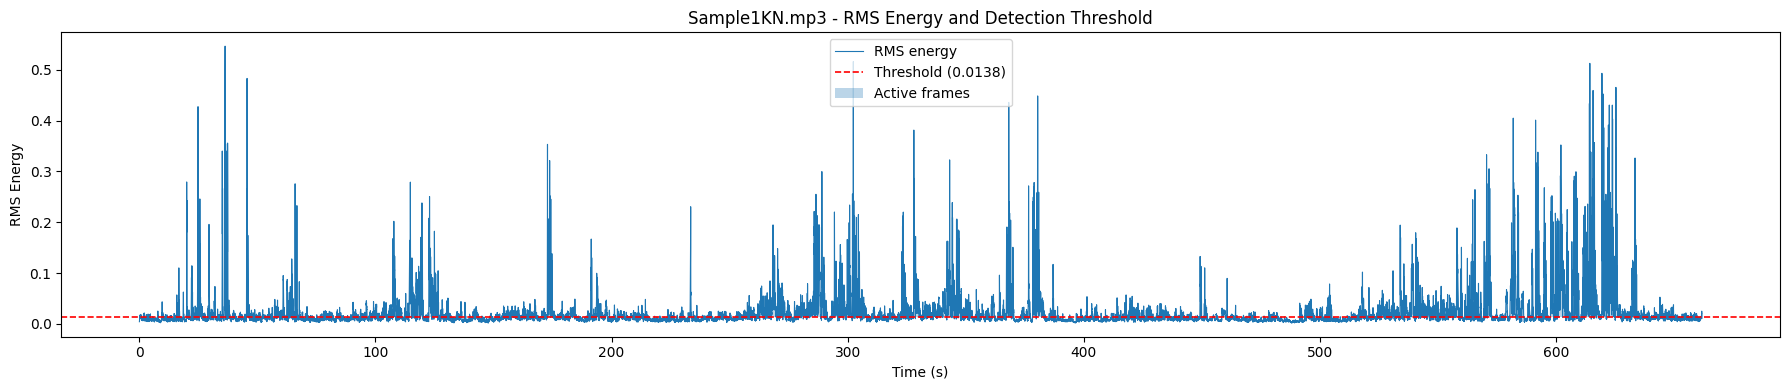

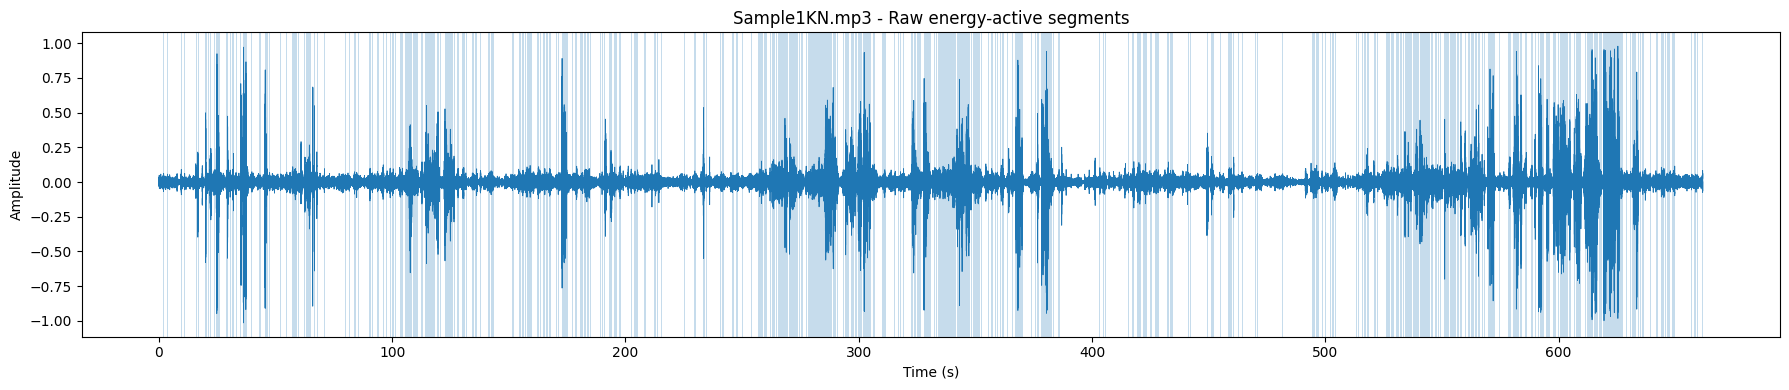

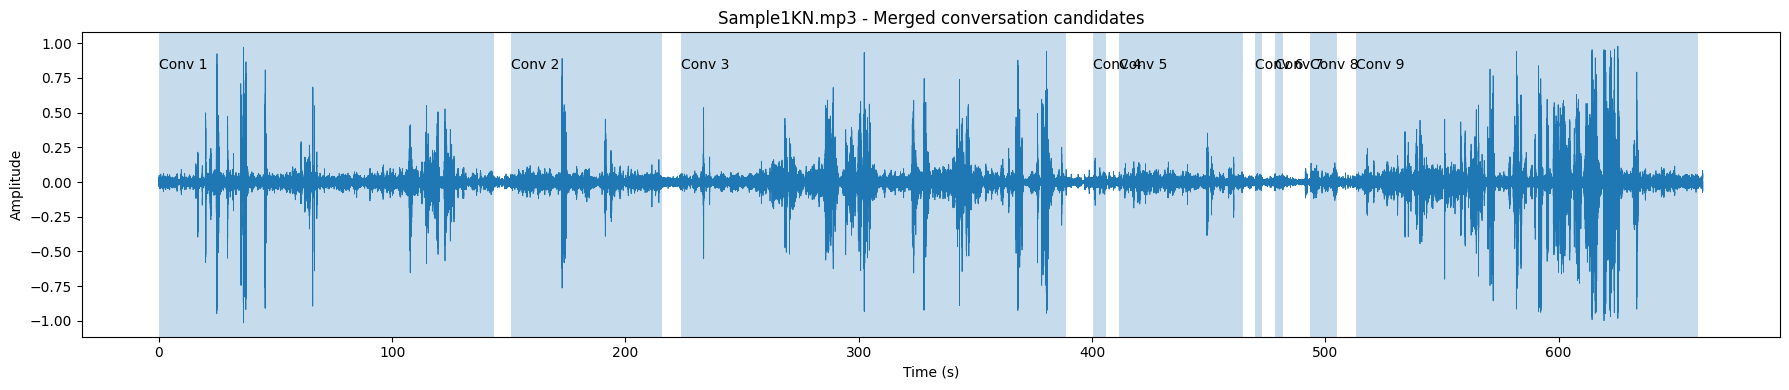

In [9]:
# Plot 1: RMS energy curve with threshold — unique to the energy baseline approach.
# This visualisation is not possible with Silero VAD (Approach 2) because the neural
# model does not expose a continuous energy/confidence curve in the same way.
plot_energy_with_threshold(
    example_result["rms"],
    example_result["energy_threshold"],
    example_result["sample_rate"],
    CONFIG["hop_length"],
    title=f"{example_result['audio_name']} - RMS Energy and Detection Threshold"
)

# Plot 2: Raw active segments on the waveform
plot_waveform_with_segments(
    example_result["waveform"],
    example_result["sample_rate"],
    example_result["speech_segments"],
    title=f"{example_result['audio_name']} - Raw energy-active segments"
)

# Plot 3: Final conversation candidates
plot_waveform_with_conversations(
    example_result["waveform"],
    example_result["sample_rate"],
    example_result["conversation_candidates"],
    title=f"{example_result['audio_name']} - Merged conversation candidates"
)
